In [1]:
print('hello from group 19!!')

hello from group 19!!


In [2]:
print("This is a test push - Jayanth")

This is a test push - Jayanth


In [3]:

import yaml

yaml_path = "GWOSC API.yaml"

with open(yaml_path, "r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

print(config)

{'openapi': '3.1.0', 'info': {'title': 'GWOSC API', 'version': '2.0.0', 'description': 'REST Public Interface to the Gravitational Wave Open Science Center database'}, 'paths': {'/api/v2/': {'get': {'operationId': 'root_retrieve', 'description': 'Example links to all API nodes.', 'security': [{'cookieAuth': []}, {'basicAuth': []}, {}], 'responses': {'200': {'content': {'application/json': {'schema': {'type': 'object', 'additionalProperties': {'type': 'object', 'additionalProperties': {'type': 'url'}}}, 'examples': {'ExampleResponse': {'value': {'Runs': {'Runs': 'http://127.0.0.1:8000/api/v2/runs'}, 'Catalogs': {'Catalogs': 'http://127.0.0.1:8000/api/v2/catalogs'}, 'Events': {'Events': 'http://127.0.0.1:8000/api/v2/events'}, 'Event versions': {'Event versions': 'http://127.0.0.1:8000/api/v2/event-versions'}, 'Parameters': {'Default parameters': 'http://127.0.0.1:8000/api/v2/default-parameters'}, 'Segments': {'Segments for a timeline (e.g. H1_DATA)': 'http://127.0.0.1:8000/api/v2/timelin

In [4]:

import pkg_resources
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform

hp, hc = get_td_waveform(
    approximant="IMRPhenomD", # Standard waveform model
    mass1=30,                 # Mass of first black hole (Solar Masses)
    mass2=30,                 # Mass of second black hole (Solar Masses)
    delta_t=1.0/4096,         # Time step size
    f_lower=30                # Starting frequency of the wave (Hz)
)

plt.figure(figsize=(10, 4))
plt.plot(hp.sample_times, hp, label="Plus Polarization", color="royalblue")
plt.plot(hc.sample_times, hc, label="Cross Polarization", color="orange", alpha=0.7)

plt.show()


ModuleNotFoundError: No module named 'pkg_resources'

In [ ]:
%pip install -q --upgrade pycbc

Note: you may need to restart the kernel to use updated packages.


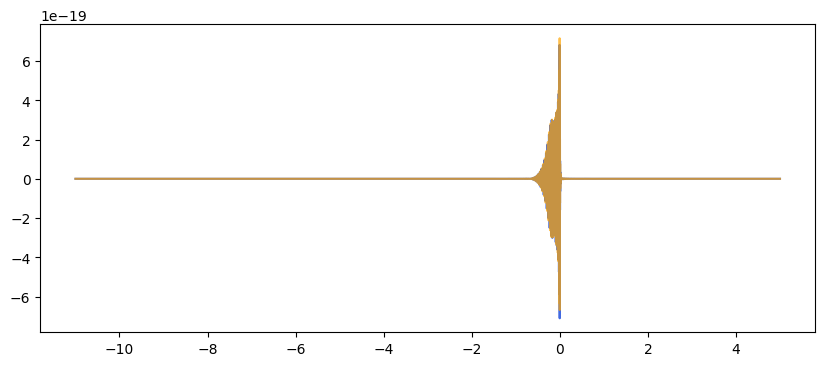

In [12]:
import matplotlib.pyplot as plt
from pycbc.waveform import get_td_waveform

hp, hc = get_td_waveform(
    approximant="IMRPhenomD", # Standard waveform model
    mass1=30,                 # Mass of first black hole (Solar Masses)
    mass2=30,                 # Mass of second black hole (Solar Masses)
    delta_t=1.0/4096,         # Time step size
    f_lower=30                # Starting frequency of the wave (Hz)
)

plt.figure(figsize=(10, 4))
plt.plot(hp.sample_times, hp, label="Plus Polarization", color="royalblue")
plt.plot(hc.sample_times, hc, label="Cross Polarization", color="orange", alpha=0.7)

plt.show()


In [22]:
import yaml
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

YAML_PATH = "/Users/oguzkirmizi/Desktop/academics/code:astro/group19_codeastro/GWOSC API.yaml"
BASE_URL = "https://gwosc.org"

with open(YAML_PATH, "r") as f:
    spec = yaml.safe_load(f)

event_versions_path = "/api/v2/event-versions"

def fetch_all(path, params):
    url = BASE_URL + path
    rows = []

    while url:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        rows.extend(data["results"])
        url = data["next"]
        params = None

    return rows

events = fetch_all(
    event_versions_path,
    {
        "format": "json",
        "release": "GWTC-1-confident,GWTC-2.1-confident,GWTC-3-confident",
        "lastver": "true",
        "include-default-parameters": "true",
        "pagesize": 100,
    }
)

rows = []

for event in events:
    row = {
        "name": event.get("name"),
        "shortName": event.get("shortName"),
        "gps": event.get("gps"),
        "version": event.get("version"),
        "catalog": event.get("catalog"),
        "detectors": ",".join(event.get("detectors", [])),
        "detail_url": event.get("detail_url"),
    }

    for param in event.get("default_parameters", []):
        name = param["name"]
        row[name] = param.get("best")
        row[f"{name}_upper_error"] = param.get("upper_error")
        row[f"{name}_lower_error"] = param.get("lower_error")
        row[f"{name}_unit"] = param.get("unit")

    rows.append(row)

df = pd.DataFrame(rows)
df = df.dropna(subset=["mass_1_source", "mass_2_source"])
df = df.sort_values("gps").reset_index(drop=True)

df.head()

,name,shortName,gps,version,catalog,detectors,detail_url,chirp_mass_source,chirp_mass_source_upper_error,chirp_mass_source_lower_error,...,total_mass_source_lower_error,total_mass_source_unit,far,far_upper_error,far_lower_error,far_unit,p_astro,p_astro_upper_error,p_astro_lower_error,p_astro_unit
0,GW150914,GW150914-v4,1.126259e+09,4,GWTC-2.1-confident,"H1,L1",https://gwosc.org/api/v2/event-versions/GW1509...,27.9,1.7,-1.5,...,-3.2,M_sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GW151012,GW151012-v4,1.128679e+09,4,GWTC-2.1-confident,"H1,L1",https://gwosc.org/api/v2/event-versions/GW1510...,15.6,2.3,-1.5,...,-4.7,M_sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GW151226,GW151226-v3,1.135136e+09,3,GWTC-2.1-confident,"H1,L1",https://gwosc.org/api/v2/event-versions/GW1512...,8.9,0.3,-0.3,...,-1.6,M_sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,GW170104,GW170104-v3,1.167560e+09,3,GWTC-2.1-confident,"H1,L1",https://gwosc.org/api/v2/event-versions/GW1701...,21.1,2.0,-1.5,...,-3.6,M_sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GW170608,GW170608-v4,1.180922e+09,4,GWTC-2.1-confident,L1,https://gwosc.org/api/v2/event-versions/GW1706...,7.9,0.2,-0.2,...,-0.6,M_sun,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
blue = "#00a9e0"
orange = "#d9901a"
gray = "#8a8a8a"

fig, ax = plt.subplots(figsize=(13, 7), facecolor="black")
ax.set_facecolor("black")

x = np.arange(len(df))

for i, row in df.iterrows():
    m1 = row["mass_1_source"]
    m2 = row["mass_2_source"]
    mf = row.get("final_mass_source", np.nan)

    c1 = orange if m1 < 3 else blue
    c2 = orange if m2 < 3 else blue

    if pd.notna(mf):
        ax.plot([i, i], [min(m1, m2), mf], color=gray, alpha=0.65, linewidth=1.2)
        ax.scatter(i, mf, color=blue, s=90, edgecolor="black", linewidth=0.4, zorder=4)

    ax.scatter(i, m1, color=c1, s=42, edgecolor="black", linewidth=0.4, zorder=5)
    ax.scatter(i, m2, color=c2, s=42, edgecolor="black", linewidth=0.4, zorder=5)

ax.set_yscale("log")
ax.set_ylim(1, 220)
ax.set_xlim(-1, len(df))

ax.set_yticks([1, 2, 5, 10, 20, 50, 100, 200])
ax.set_yticklabels(["1", "2", "5", "10", "20", "50", "100", "200"], color="gray")

ax.set_xticks([])
ax.set_ylabel("Solar Masses", color="gray", fontsize=14)
ax.set_title("Masses in the Stellar Graveyard", color="white", fontsize=30, pad=22)

ax.grid(axis="y", color="white", alpha=0.18, linewidth=1)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_items = [
    Line2D([0], [0], marker="o", color="none", label="LIGO-Virgo-KAGRA Black Holes",
           markerfacecolor=blue, markersize=9),
    Line2D([0], [0], marker="o", color="none", label="LIGO-Virgo-KAGRA Neutron Stars",
           markerfacecolor=orange, markersize=9),
]

leg = ax.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, 1.02),
                ncol=2, frameon=False)

for text, color in zip(leg.get_texts(), [blue, orange]):
    text.set_color(color)

plt.tight_layout()
plt.show()

/var/folders/kw/5dwjzsc16_x38klmnyw2xmyr0000gn/T/ipykernel_52968/3663820193.py:25: UserWarning: Data has no values between 0 and 1, and therefore cannot be logit-scaled.
  ax.set_yscale("logit")
/var/folders/kw/5dwjzsc16_x38klmnyw2xmyr0000gn/T/ipykernel_52968/3663820193.py:26: UserWarning: Data has no values between 0 and 1, and therefore cannot be logit-scaled.
  ax.set_ylim(1, 220)
/opt/miniconda3/envs/codeastro/lib/python3.10/site-packages/matplotlib/transforms.py:2652: RuntimeWarning: divide by zero encountered in scalar divide
  y_scale = 1.0 / inh
/opt/miniconda3/envs/codeastro/lib/python3.10/site-packages/matplotlib/ticker.py:2824: RuntimeWarning: invalid value encountered in log10
  np.ceil(np.log10(vmax))


ValueError: cannot convert float NaN to integer

Error in callback <function _draw_all_if_interactive at 0x12bccb370> (for post_execute), with arguments args (),kwargs {}:


ValueError: cannot convert float NaN to integer

ValueError: cannot convert float NaN to integer

<Figure size 1300x700 with 1 Axes>

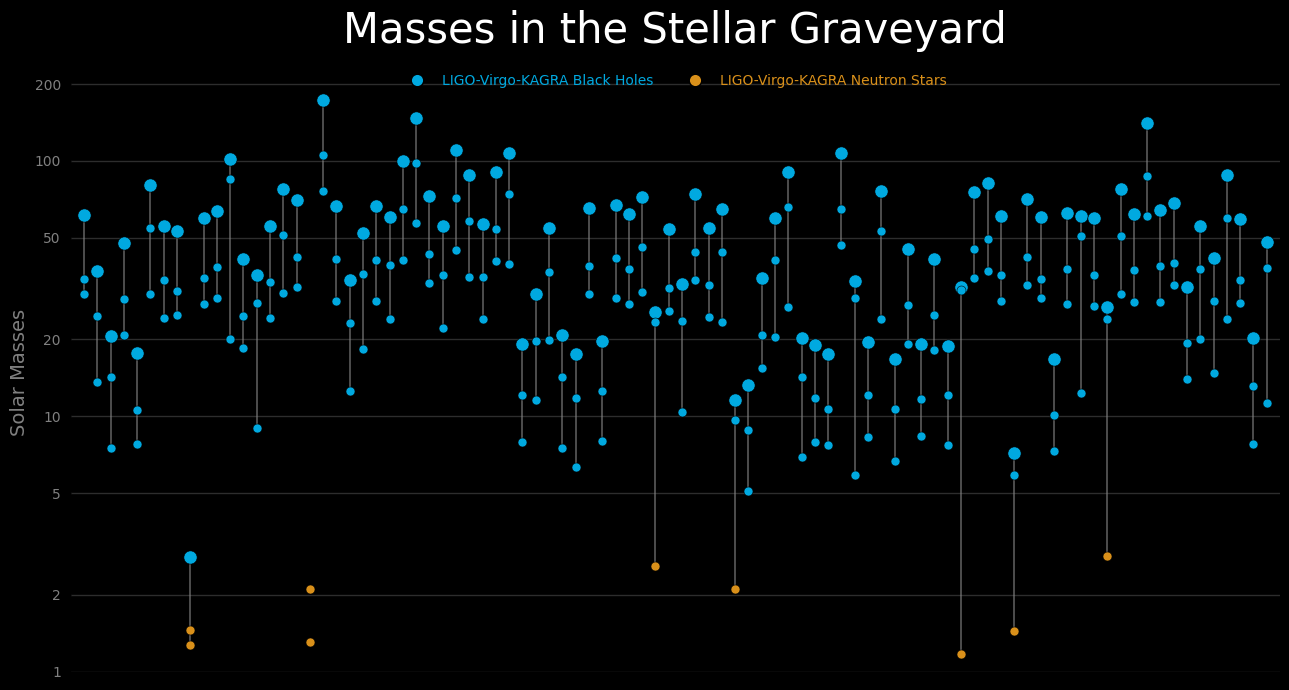

In [28]:
import yaml
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

YAML_PATH = "/Users/oguzkirmizi/Desktop/academics/code:astro/group19_codeastro/GWOSC API.yaml"
BASE_URL = "https://gwosc.org"

with open(YAML_PATH, "r") as f:
    spec = yaml.safe_load(f)

event_versions_path = "/api/v2/event-versions"

def fetch_all(path, params):
    url = BASE_URL + path
    rows = []

    while url:
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        rows.extend(data["results"])
        url = data["next"]
        params = None

    return rows

events = fetch_all(
    event_versions_path,
    {
        "format": "json",
        "release": "GWTC-1-confident,GWTC-2.1-confident,GWTC-3-confident",
        "lastver": "true",
        "include-default-parameters": "true",
        "pagesize": 100,
    }
)

rows = []

for event in events:
    row = {
        "name": event.get("name"),
        "shortName": event.get("shortName"),
        "gps": event.get("gps"),
        "version": event.get("version"),
        "catalog": event.get("catalog"),
        "detectors": ",".join(event.get("detectors", [])),
        "detail_url": event.get("detail_url"),
    }

    for param in event.get("default_parameters", []):
        name = param["name"]
        row[name] = param.get("best")
        row[f"{name}_upper_error"] = param.get("upper_error")
        row[f"{name}_lower_error"] = param.get("lower_error")
        row[f"{name}_unit"] = param.get("unit")

    rows.append(row)

df = pd.DataFrame(rows)
df = df.dropna(subset=["mass_1_source", "mass_2_source"])
df = df.sort_values("gps").reset_index(drop=True)

def plot_masses(dataframe):
    blue = "#00a9e0"
    orange = "#d9901a"
    gray = "#8a8a8a"

    fig, ax = plt.subplots(figsize=(13, 7), facecolor="black")
    ax.set_facecolor("black")

    x = np.arange(len(dataframe))

    for i, row in dataframe.iterrows():
        m1 = row["mass_1_source"]
        m2 = row["mass_2_source"]
        mf = row.get("final_mass_source", np.nan)

        c1 = orange if m1 < 3 else blue
        c2 = orange if m2 < 3 else blue 
        
        if pd.notna(mf):
            ax.plot([i, i], [min(m1, m2), mf], color=gray, alpha=0.65, linewidth=1.2)
            ax.scatter(i, mf, color=blue, s=90, edgecolor="black", linewidth=0.4, zorder=4)
        ax.scatter(i, m1, color=c1, s=42, edgecolor="black", linewidth=0.4, zorder=5)
        ax.scatter(i, m2, color=c2, s=42, edgecolor="black", linewidth=0.4, zorder=5)
    ax.set_yscale("log")
    ax.set_ylim(1, 220)
    ax.set_xlim(-1, len(df))

    ax.set_yticks([1, 2, 5, 10, 20, 50, 100, 200])
    ax.set_yticklabels(["1", "2", "5", "10", "20", "50", "100", "200"], color="gray")

    ax.set_xticks([])
    ax.set_ylabel("Solar Masses", color="gray", fontsize=14)
    ax.set_title("Masses in the Stellar Graveyard", color="white", fontsize=30, pad=22)

    ax.grid(axis="y", color="white", alpha=0.18, linewidth=1)

    for spine in ax.spines.values():
        spine.set_visible(False)

    legend_items = [
        Line2D([0], [0], marker="o", color="none", label="LIGO-Virgo-KAGRA Black Holes",
            markerfacecolor=blue, markersize=9),
        Line2D([0], [0], marker="o", color="none", label="LIGO-Virgo-KAGRA Neutron Stars",
            markerfacecolor=orange, markersize=9),
    ]

    leg = ax.legend(handles=legend_items, loc="upper center", bbox_to_anchor=(0.5, 1.02),
                    ncol=2, frameon=False)

    for text, color in zip(leg.get_texts(), [blue, orange]):
        text.set_color(color)

    plt.tight_layout()
    plt.show()
    
plot_masses(df)    

In [ ]:
from pathlib import Path
import argparse
import yaml


def load_config(yaml_path):
    yaml_path = Path(yaml_path)

    if not yaml_path.exists():
        raise FileNotFoundError(f"YAML file not found: {yaml_path}")

    with open(yaml_path, "r") as file:
        return yaml.safe_load(file)
    
def get_yaml(yaml_path):
    config = load_config(yaml_path)

    print("Loaded config:")
    print(config)



def run_argument():
    parser = argparse.ArgumentParser()
    parser.add_argument(
        "yaml_path",
        help="Path to the YAML configuration file"
    )

    args = parser.parse_args()

    get_yaml(args.yaml_path)


get_yaml("/Users/oguzkirmizi/Desktop/academics/code:astro/group19_codeastro/GWOSC API.yaml")

Loaded config:
{'openapi': '3.1.0', 'info': {'title': 'GWOSC API', 'version': '2.0.0', 'description': 'REST Public Interface to the Gravitational Wave Open Science Center database'}, 'paths': {'/api/v2/': {'get': {'operationId': 'root_retrieve', 'description': 'Example links to all API nodes.', 'security': [{'cookieAuth': []}, {'basicAuth': []}, {}], 'responses': {'200': {'content': {'application/json': {'schema': {'type': 'object', 'additionalProperties': {'type': 'object', 'additionalProperties': {'type': 'url'}}}, 'examples': {'ExampleResponse': {'value': {'Runs': {'Runs': 'http://127.0.0.1:8000/api/v2/runs'}, 'Catalogs': {'Catalogs': 'http://127.0.0.1:8000/api/v2/catalogs'}, 'Events': {'Events': 'http://127.0.0.1:8000/api/v2/events'}, 'Event versions': {'Event versions': 'http://127.0.0.1:8000/api/v2/event-versions'}, 'Parameters': {'Default parameters': 'http://127.0.0.1:8000/api/v2/default-parameters'}, 'Segments': {'Segments for a timeline (e.g. H1_DATA)': 'http://127.0.0.1:8000